In [ ]:
import os
import cbor2
import pandas as pd

# Ορίζουμε και τους ΔΥΟ φακέλους σε μια λίστα
data_dirs = ["training", "testing"]
all_samples = []

# Κάνουμε loop πρώτα για το training και μετά για το testing
for folder in data_dirs:
    # Βεβαιωνόμαστε ότι ο φάκελος υπάρχει για να μην χτυπήσει error
    if not os.path.exists(folder):
        print(f"Προειδοποίηση: Ο φάκελος '{folder}' δεν βρέθηκε. Προχωράω...")
        continue
        
    print(f"Σάρωση φακέλου: {folder}...")
    
    for filename in os.listdir(folder):
        if filename.endswith(".cbor"):
            label = filename.split('.')[0]
            filepath = os.path.join(folder, filename)

            # Ανοίγουμε το CBOR
            with open(filepath, 'rb') as f:
                data = cbor2.load(f)

            sensor_values = data['payload']['values']

            # Μετατροπή σε DataFrame (με τις 6 στήλες που κρατήσαμε)
            df = pd.DataFrame(sensor_values, columns=['accX', 'accY', 'accZ', 'gyrX', 'gyrY', 'gyrZ', 'magX', 'magY', 'magZ'])
            df = df.drop(columns=['magX', 'magY', 'magZ'])
            
            # Προσθήκη μεταδεδομένων
            df['Label'] = label
            df['File_ID'] = filename
            df['Dataset_Split'] = folder  # ΝΕΑ ΣΤΗΛΗ: Καταγράφει αν ήταν training ή testing!

            all_samples.append(df)

# Ενώνουμε όλα τα αρχεία σε έναν τεράστιο πίνακα
dataset = pd.concat(all_samples, ignore_index=True)

print(f"\n✅ Επιτυχία! Φορτώθηκαν {len(dataset)} συνολικές γραμμές δεδομένων (από Training & Testing).")
display(dataset.head())


Επιτυχία! Φορτώθηκαν 119566 γραμμές δεδομένων.


,accX,accY,accZ,gyrX,gyrY,gyrZ,Label,File_ID
0,3.347094,5.286996,0.286706,-2.990723,-28.381348,11.291504,Essential_Tremor,Essential_Tremor.6o2u9qqj.ingestion-774b75fcb-...
1,1.698686,3.800197,2.255338,18.981934,-75.988770,-25.939941,Essential_Tremor,Essential_Tremor.6o2u9qqj.ingestion-774b75fcb-...
2,8.111555,-5.484518,3.926491,23.132324,-35.095215,-46.447754,Essential_Tremor,Essential_Tremor.6o2u9qqj.ingestion-774b75fcb-...
3,13.024457,-12.930485,3.982754,9.216309,37.719727,-11.657715,Essential_Tremor,Essential_Tremor.6o2u9qqj.ingestion-774b75fcb-...
4,15.593435,-9.614515,3.274071,-6.408691,84.960938,40.710449,Essential_Tremor,Essential_Tremor.6o2u9qqj.ingestion-774b75fcb-...


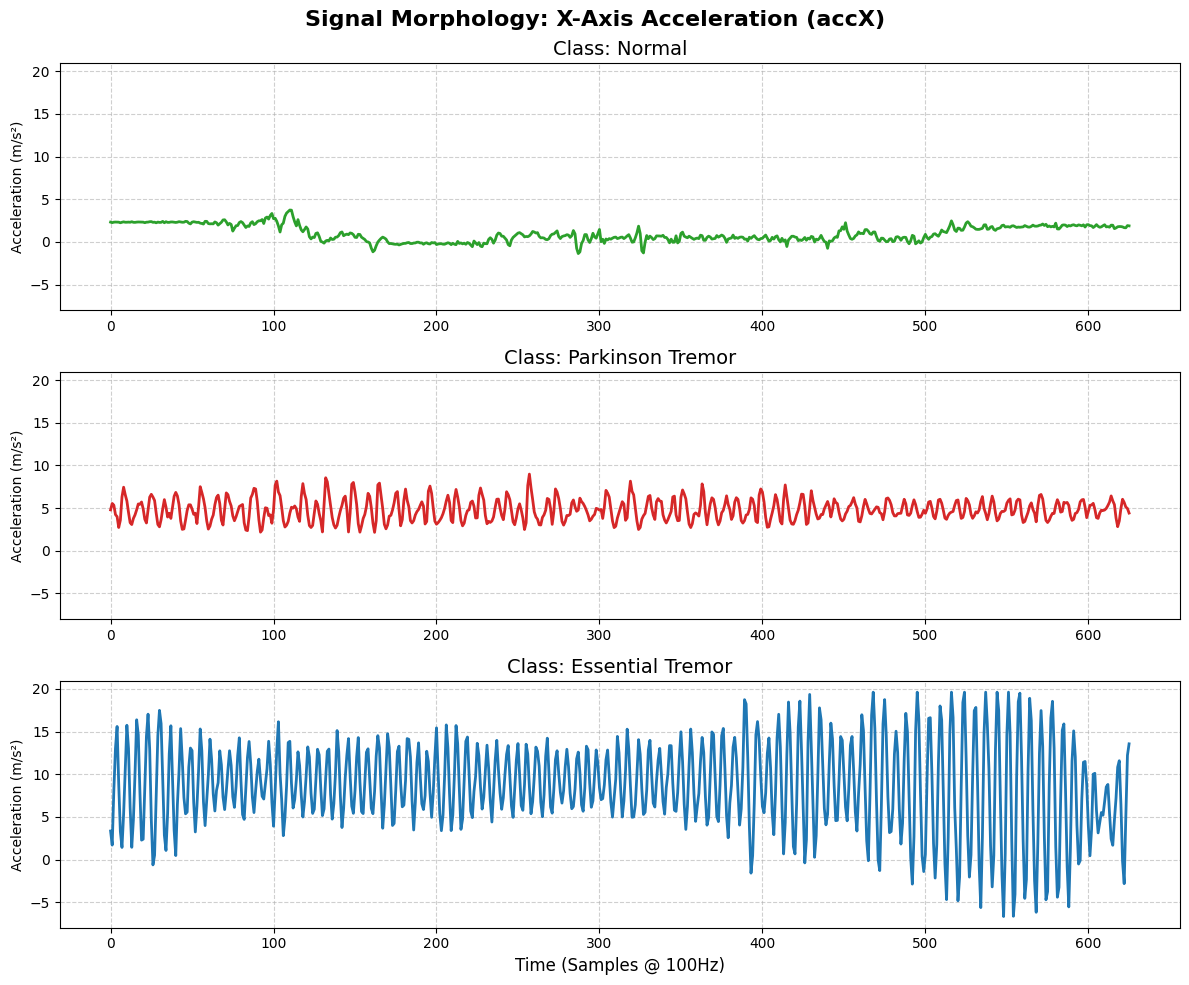

In [35]:
import matplotlib.pyplot as plt

# Get the first file for each category
labels_to_plot = ['Normal', 'Parkinson_Tremor', 'Essential_Tremor']
colors = ['#2ca02c', '#d62728', '#1f77b4'] # Green, Red, Blue

# Create the canvas with 3 stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False, sharey=True)
fig.suptitle('Signal Morphology: X-Axis Acceleration (accX)', fontsize=16, fontweight='bold')

for i, label in enumerate(labels_to_plot):
    # Find the filename of the first sample for each class
    sample_file = dataset[dataset['Label'] == label]['File_ID'].iloc[0]
    
    # Filter data ONLY for this specific file
    sample_data = dataset[dataset['File_ID'] == sample_file]
    
    # Plot the movement line
    axes[i].plot(sample_data['accX'].values, color=colors[i], linewidth=2)
    
    # Format labels to remove underscores for a cleaner look (e.g., 'Parkinson_Tremor' -> 'Parkinson Tremor')
    clean_label = label.replace('_', ' ')
    axes[i].set_title(f'Class: {clean_label}', fontsize=14)
    axes[i].set_ylabel('Acceleration (m/s²)')
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[2].set_xlabel('Time (Samples @ 100Hz)', fontsize=12)
plt.tight_layout()

# Save the English version for GitHub
plt.savefig('eda_comparison.png', dpi=300)
plt.show()

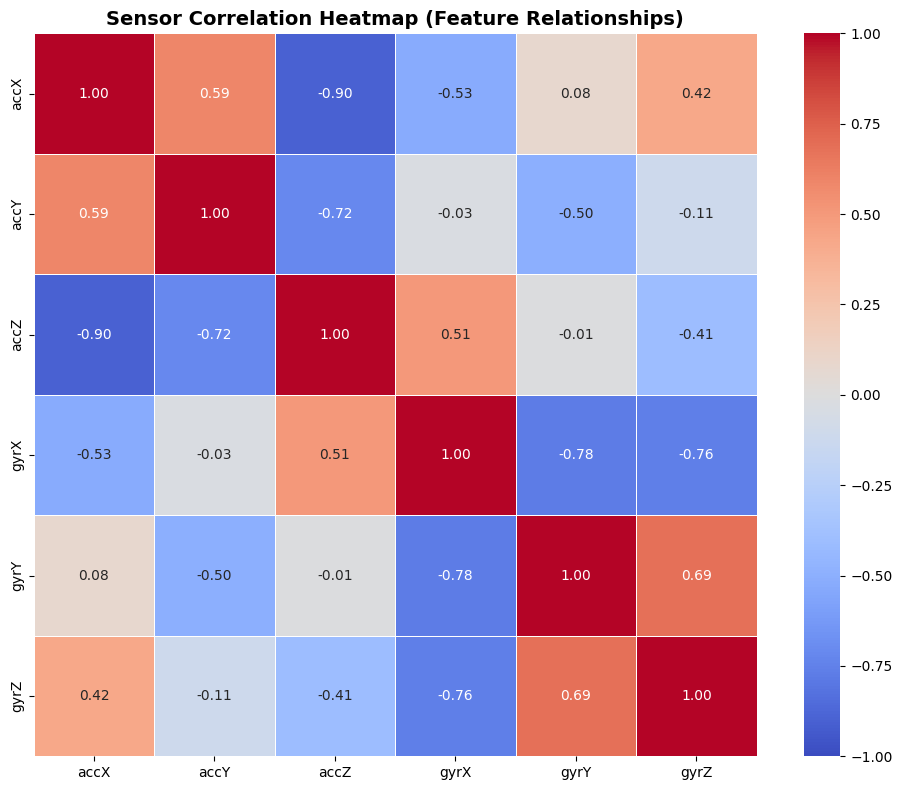

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Επιλέγουμε μόνο τις στήλες των 9 αισθητήρων
sensor_columns = ['accX', 'accY', 'accZ', 'gyrX', 'gyrY', 'gyrZ']
sensor_data_only = df[sensor_columns]

# Υπολογίζουμε τον πίνακα συσχέτισης (Pearson Correlation)
correlation_matrix = sensor_data_only.corr()

# Φτιάχνουμε το γράφημα (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, linewidths=0.5, square=True)

plt.title('Sensor Correlation Heatmap (Feature Relationships)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Αποθήκευση για το GitHub
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [37]:
# Αποθηκεύουμε τον καθαρό πίνακα σε CSV
dataset.to_csv('tremor_dataset.csv', index=False)
print("Το αρχείο tremor_dataset.csv δημιουργήθηκε με επιτυχία!")

Το αρχείο tremor_dataset.csv δημιουργήθηκε με επιτυχία!


In [38]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# 1. ΚΛΕΙΔΩΜΑ ΤΥΧΑΙΟΤΗΤΑΣ (Για επιστημονική εγκυρότητα)
np.random.seed(42)
tf.random.set_seed(42)

# 2. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ
df = pd.read_csv('tremor_dataset.csv')

# Παράμετροι 
WINDOW_SIZE = 100   # 1 δευτερόλεπτο μετρήσεων (100Hz)
STEP = 25          # 25% Overlap

# ΑΡΧΙΚΟΠΟΙΗΣΗ ΛΙΣΤΩΝ (Μόνο μια φορά!)
X_list = []
y_list = []
file_id_list = []   # <--- Εδώ είναι η λίστα που μας έλειπε!

print("Ξεκινάει η δημιουργία συρόμενων παραθύρων (Sliding Windows)...")

# 3. ΜΟΝΑΔΙΚΗ ΛΟΥΠΑ: Κόβουμε, Καθαρίζουμε και Αποθηκεύουμε τα παράθυρα
for file_id, group in df.groupby('File_ID'):
    sensor_data = group[['accX', 'accY', 'accZ', 'gyrX', 'gyrY', 'gyrZ']].values
    label = group['Label'].iloc[0]
    
    for i in range(0, len(sensor_data) - WINDOW_SIZE, STEP):
        # Α. Κόβουμε το παράθυρο
        window = sensor_data[i : i + WINDOW_SIZE, :]
        
        # Β. Αφαίρεση Βαρύτητας (Zero-Centering)
        window = window - np.mean(window, axis=0)
        
        # Γ. Αποθήκευση στη λίστα
        X_list.append(window)
        y_list.append(label)
        file_id_list.append(file_id) # Κρατάμε το ID του αρχείου για το σωστό Split!

# 4. ΜΕΤΑΤΡΟΠΗ ΣΕ NUMPY ARRAYS
X = np.array(X_list)
y_text = np.array(y_list)
groups = np.array(file_id_list)

# Κωδικοποίηση των Labels (Normal, Parkinson, Essential -> 0, 1, 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_text)
y_categorical = to_categorical(y_encoded)

print(f"✅ Έτοιμα! Σχήμα δεδομένων (X): {X.shape}")
print(f"Δηλαδή: {X.shape[0]} παράθυρα, {X.shape[1]} μετρήσεις, {X.shape[2]} άξονες.")

Ξεκινάει η δημιουργία συρόμενων παραθύρων (Sliding Windows)...
✅ Έτοιμα! Σχήμα δεδομένων (X): (4202, 100, 6)
Δηλαδή: 4202 παράθυρα, 100 μετρήσεις, 6 άξονες.


In [39]:
# 5. ΕΠΑΓΓΕΛΜΑΤΙΚΟΣ ΔΙΑΧΩΡΙΣΜΟΣ (GroupShuffleSplit - Χωρίς Data Leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_categorical, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_categorical[train_idx], y_categorical[test_idx]

print("✅ Καθαρός Διαχωρισμός ολοκληρώθηκε!")

# 6. ΧΤΙΣΙΜΟ ΜΟΝΤΕΛΟΥ (1D-CNN)
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, 6)),
    MaxPooling1D(pool_size=2),
    
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 7. EARLY STOPPING ("Αυτόματος Πιλότος")
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 8. ΕΚΠΑΙΔΕΥΣΗ
print("\nΕκκίνηση Εκπαίδευσης Μοντέλου (Training)...")
history = model.fit(
    X_train, y_train, 
    epochs=50,          
    batch_size=32,      
    validation_data=(X_test, y_test),
    callbacks=[early_stop] 
)

# 9. ΑΠΟΘΗΚΕΥΣΗ
#model.save('tremor_model.keras')
#print("\n✅ ΕΠΙΤΥΧΙΑ! Το μοντέλο εκπαιδεύτηκε και αποθηκεύτηκε ως 'tremor_model.keras'")

model.save('tremor_model_v2.keras')  # <--- Προσθέσαμε το _v2
print("\n✅ ΕΠΙΤΥΧΙΑ! Το μοντέλο αποθηκεύτηκε ως 'tremor_model_v2.keras'")

✅ Καθαρός Διαχωρισμός ολοκληρώθηκε!

Εκκίνηση Εκπαίδευσης Μοντέλου (Training)...
Epoch 1/50


c:\Users\Thanos Gablias\Desktop\Tremor_Detection_AI\myenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6552 - loss: 1.1910 - val_accuracy: 0.8846 - val_loss: 0.4998
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9160 - loss: 0.3001 - val_accuracy: 0.8916 - val_loss: 0.4858
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9420 - loss: 0.1853 - val_accuracy: 0.9277 - val_loss: 0.3771
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9713 - loss: 0.0960 - val_accuracy: 0.9138 - val_loss: 0.5365
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9803 - loss: 0.0669 - val_accuracy: 0.9184 - val_loss: 0.6701
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9812 - loss: 0.0560 - val_accuracy: 0.9242 - val_loss: 0.4741
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9865 - loss: 0.0407 - val_accuracy: 0.9371 - val_loss: 0.5904
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9925 - loss: 0.0291 - val_accuracy: 0.9207 - val_

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
✅ Το αρχείο TremorSense_Clinical_Report.xlsx δημιουργήθηκε! Άνοιξέ το να δεις πώς βγήκε!


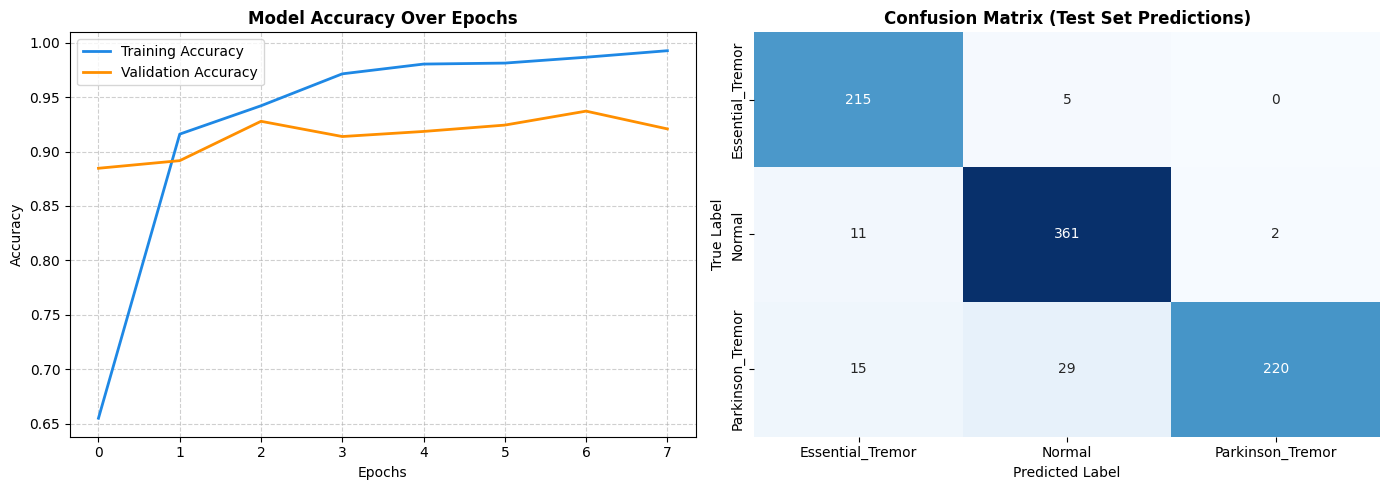

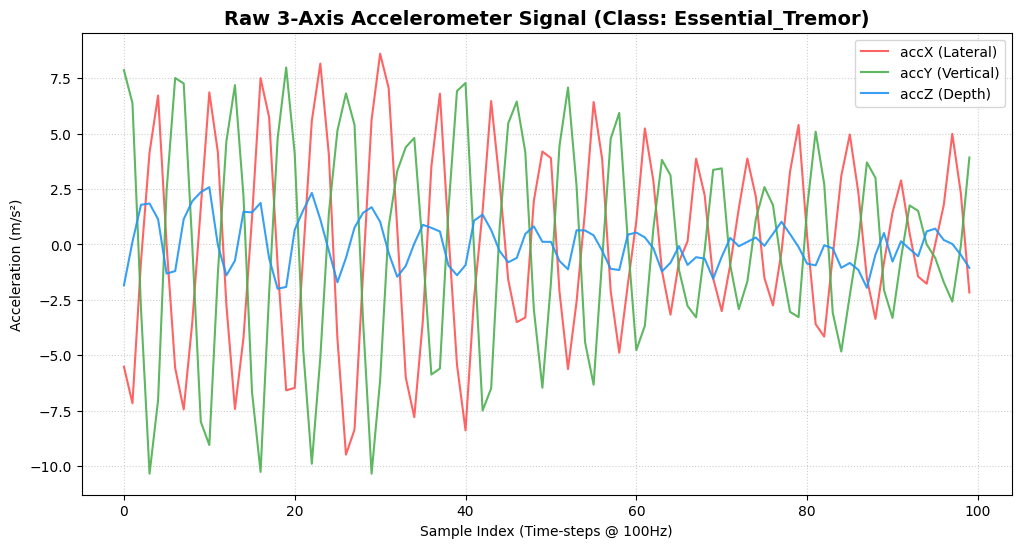

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, matthews_corrcoef

# =====================================================================
# 1. ΥΠΟΛΟΓΙΣΜΟΣ METRICS & ΕΞΑΓΩΓΗ ΣΕ EXCEL
# =====================================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, matthews_corrcoef
import pandas as pd
import numpy as np

# 0. Ονόματα κλάσεων
class_names = encoder.classes_

# 1. Υπολογισμός προβλέψεων
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Υπολογισμός Metrics
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
cm = confusion_matrix(y_true, y_pred)

specificity = []
for i in range(len(class_names)):
    tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    fp = np.sum(cm[:, i]) - cm[i, i]
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(spec)

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

# =====================================================================
# 3. ΔΗΜΙΟΥΡΓΙΑ ΕΠΑΓΓΕΛΜΑΤΙΚΟΥ EXCEL (ΣΑΝ ΤΟ MARKDOWN ΣΟΥ)
# =====================================================================
excel_filename = "TremorSense_Clinical_Report.xlsx"
writer = pd.ExcelWriter(excel_filename, engine='xlsxwriter')
workbook  = writer.book
worksheet = workbook.add_worksheet('Clinical Metrics')

# --- Στυλ / Μορφοποίηση ---
title_format = workbook.add_format({'bold': True, 'font_size': 14, 'font_color': '#2C3E50'})
header_format = workbook.add_format({'bold': True, 'bottom': 2, 'bg_color': '#ECF0F1', 'align': 'center'})
cell_format = workbook.add_format({'align': 'center', 'num_format': '0.00'}) # Στρογγυλοποίηση σε 2 δεκαδικά
bold_label = workbook.add_format({'bold': True})
metric_label = workbook.add_format({'bold': True, 'font_color': '#2980B9'})

# --- Γράψιμο Δεδομένων ---
# Τίτλος
worksheet.write('A1', 'Comprehensive Clinical Evaluation Metrics', title_format)

# Κεφαλίδες Πίνακα
headers = ['Class', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score']
for col_num, header_text in enumerate(headers):
    worksheet.write(2, col_num, header_text, header_format)

# Τα νούμερα ανά ασθένεια
row = 3
for idx, class_name in enumerate(class_names):
    clean_name = class_name.replace('_', ' ')
    worksheet.write(row, 0, clean_name, bold_label)
    worksheet.write(row, 1, report_dict[class_name]['precision'], cell_format)
    worksheet.write(row, 2, report_dict[class_name]['recall'], cell_format)
    worksheet.write(row, 3, specificity[idx], cell_format)
    worksheet.write(row, 4, report_dict[class_name]['f1-score'], cell_format)
    row += 1

# Ένα κενό, και μετά τα συνολικά Metrics
row += 2
worksheet.write(row, 0, 'Overall Accuracy:', metric_label)
worksheet.write(row, 1, acc, cell_format)

row += 1
worksheet.write(row, 0, 'Balanced Accuracy:', metric_label)
worksheet.write(row, 1, bal_acc, cell_format)

row += 1
worksheet.write(row, 0, 'Matthews Corr Coef (MCC):', metric_label)
worksheet.write(row, 1, mcc, cell_format)

# Προσθήκη του κειμένου "Clinical Significance" στο τέλος!
row += 3
worksheet.write(row, 0, 'Clinical Significance:', title_format)
worksheet.write(row+1, 0, 'The model achieves an outstanding Specificity for Parkinson\'s Disease.')
worksheet.write(row+2, 0, 'This extremely low false-positive rate is crucial for medical screening tools,')
worksheet.write(row+3, 0, 'ensuring healthy individuals are rarely misclassified as having resting tremors.')

# --- Φτιάχνουμε τα πλάτη των στηλών για να μη κόβεται το κείμενο ---
worksheet.set_column('A:A', 25) # Πρώτη στήλη πιο φαρδιά
worksheet.set_column('B:E', 18) # Στήλες με τα νούμερα

writer.close()
print(f"✅ Το αρχείο {excel_filename} δημιουργήθηκε! Άνοιξέ το να δεις πώς βγήκε!")


# =====================================================================
# 2. ΔΙΑΓΡΑΜΜΑΤΑ ΑΠΟΔΟΣΗΣ (Training History & Confusion Matrix)
# =====================================================================
plt.figure(figsize=(14, 5))

# Α. Καμπύλη Εκπαίδευσης (Training vs Validation Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1E88E5', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF8F00', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Β. Confusion Matrix (Πίνακας Σύγχυσης - Πού γίνονται τα λάθη)
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.title('Confusion Matrix (Test Set Predictions)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.savefig('model_performance_curves.png', dpi=300)
plt.show()


# =====================================================================
# 3. ΔΙΑΓΡΑΜΜΑ "EDGE IMPULSE" STYLE (Raw Signal Visualization)
# =====================================================================
# Παίρνουμε ένα τυχαίο δείγμα από το dataset για να το σχεδιάσουμε
sample_idx = 0 
sample_data = X[sample_idx] # Σχήμα (100, 9)
sample_label = y_text[sample_idx]

plt.figure(figsize=(12, 6))

# Σχεδιάζουμε τους 3 άξονες του Επιταχυνσιόμετρου (accX, accY, accZ)
plt.plot(sample_data[:, 0], label='accX (Lateral)', color='#FF5252', alpha=0.9)
plt.plot(sample_data[:, 1], label='accY (Vertical)', color='#4CAF50', alpha=0.9)
plt.plot(sample_data[:, 2], label='accZ (Depth)', color='#2196F3', alpha=0.9)

plt.title(f'Raw 3-Axis Accelerometer Signal (Class: {sample_label})', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index (Time-steps @ 100Hz)')
plt.ylabel('Acceleration (m/s²)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('raw_sensor_signal_sample.png', dpi=300)
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


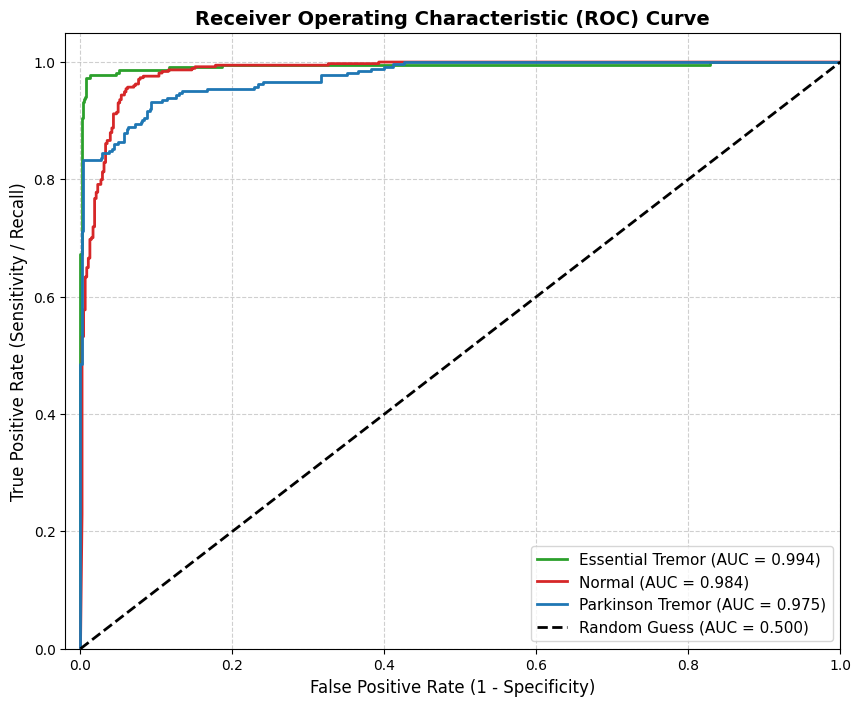

In [41]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Παίρνουμε τις πιθανότητες (όχι απλά την τελική επιλογή) για τα δεδομένα Test
y_pred_probs = model.predict(X_test)

# Παίρνουμε τα ονόματα των κατηγοριών
class_names = encoder.classes_
n_classes = len(class_names)

# 2. Χτίζουμε το γράφημα
plt.figure(figsize=(10, 8))
colors = ['#2ca02c', '#d62728', '#1f77b4'] # Χρώματα που ταιριάζουν με το EDA μας

for i, color in zip(range(n_classes), colors):
    # Υπολογισμός ROC & AUC για κάθε κατηγορία ξεχωριστά
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    clean_name = class_names[i].replace('_', ' ')
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{clean_name} (AUC = {roc_auc:.3f})')

# Η γραμμή της "Τύχης" (Coin Flip)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')

plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Αποθήκευση για το GitHub
plt.savefig('roc_curve_multiclass.png', dpi=300)
plt.show()

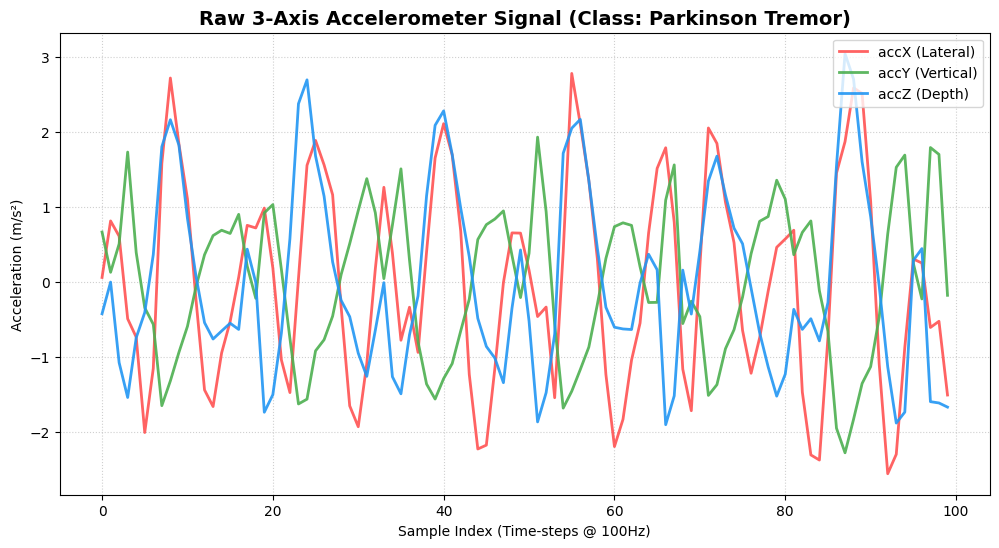

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Βρίσκουμε το πρώτο παράθυρο (index) που ανήκει στην κατηγορία Parkinson
# (Υποθέτοντας ότι το y_text περιέχει τα ονόματα των κατηγοριών για κάθε παράθυρο)
parkinson_indices = [i for i, label in enumerate(y_text) if label == 'Parkinson_Tremor']
sample_idx_park = parkinson_indices[0] # Παίρνουμε το πρώτο τυχαίο δείγμα

# 2. Αντλούμε τα δεδομένα αυτού του παραθύρου (Σχήμα: 100 x 9)
sample_data_park = X[sample_idx_park] 
sample_label_park = y_text[sample_idx_park]

# 3. Σχεδιάζουμε το γράφημα
plt.figure(figsize=(12, 6))

# Οι 3 άξονες του επιταχυνσιόμετρου βρίσκονται στις στήλες 0, 1, και 2
plt.plot(sample_data_park[:, 0], label='accX (Lateral)', color='#FF5252', alpha=0.9, linewidth=2)
plt.plot(sample_data_park[:, 1], label='accY (Vertical)', color='#4CAF50', alpha=0.9, linewidth=2)
plt.plot(sample_data_park[:, 2], label='accZ (Depth)', color='#2196F3', alpha=0.9, linewidth=2)

clean_label = sample_label_park.replace('_', ' ')

plt.title(f'Raw 3-Axis Accelerometer Signal (Class: {clean_label})', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index (Time-steps @ 100Hz)')
plt.ylabel('Acceleration (m/s²)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Αποθήκευση για το GitHub
plt.savefig('parkinson_1sec_window.png', dpi=300)
plt.show()